In [1]:
import base64
import cv2
import math
import numpy as np
import selenium.webdriver.support.expected_conditions as EC
import time

from kataho.kataho import KatahoSDK
from math import radians, sin, cos, sqrt, atan2, asin, degrees
from selenium import webdriver
from selenium.webdriver.common import by, keys
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.common.action_chains import ActionChains
# from src.app.core import configs 
# from src.app.core import globals
# from src.app.utils.server import Server


In [4]:
def haversine(coord1, coord2):
    # Radius of Earth in kilometers
    R = 6371.0
    
    # Coordinates in radians
    lat1, lon1 = radians(coord1[0]), radians(coord1[1])
    lat2, lon2 = radians(coord2[0]), radians(coord2[1])
    
    # Differences in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine formula
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
    # Distance in kilometers
    distance = R * c
    return distance * 1000  # Convert to meters

def move_point_by_distance(lat, lon, distance_in_meters, bearing):
    """
    bearing: The direction of movement (in degrees). 0° = North, 90° = East, 180° = South, 270° = West.
    """
    # Radius of the Earth in meters
    R = 6371000
    
    # Convert latitude and longitude from degrees to radians
    lat = radians(lat)
    lon = radians(lon)
    
    # Convert bearing to radians
    bearing = radians(bearing)
    
    # Calculate the new latitude
    new_lat = asin(
        sin(lat) * cos(distance_in_meters / R) +
        cos(lat) * sin(distance_in_meters / R) * cos(bearing)
    )
    
    # Calculate the new longitude
    new_lon = lon + atan2(
        sin(bearing) * sin(distance_in_meters / R) * cos(lat),
        cos(distance_in_meters / R) - sin(lat) * sin(new_lat)
    )
    
    # Convert back to degrees
    new_lat = degrees(new_lat)
    new_lon = degrees(new_lon)
    
    return new_lat, new_lon

In [3]:
driver = webdriver.Chrome()
wait = WebDriverWait(driver, 2)
server = Server()

driver.maximize_window()

driver.get(configs.MAP_URL)
driver.implicitly_wait(0.5)

d:\Mausam\Learn\Kataho\Tile-Concat\venv\Lib\site-packages\selenium\webdriver\common\windows\selenium-manager.exe --browser chrome --language-binding python --output json
C:\Users\devai\.cache\selenium\chromedriver\win64\128.0.6613.119\chromedriver.exe --port=59213


In [4]:
if globals.REPEAT_OK_CLICK and globals.LOCAL:
    try:
        ok_btn = wait.until(EC.element_to_be_clickable((by.By.CSS_SELECTOR, 'button.dismissButton')))
        ok_btn.click()
        globals.REPEAT_OK_CLICK = False
    except Exception as e:
        print(e)

# ok_btn = driver.find_element(by.By.CSS_SELECTOR, 'button.dismissButton')
# ok_btn.click()

In [5]:
if globals.REPEAT_GRID_CLICK:
    try:
        grid = wait.until(EC.element_to_be_clickable((by.By.CLASS_NAME, 'map-control')))
        
        grid.click()
        globals.REPEAT_GRID_CLICK = False
    except Exception as e:
        print(e)

In [6]:
# zomming out
actions = ActionChains(driver)

for _ in range(2):
    for _ in range(2):
        actions.context_click().perform()
        time.sleep(0.01)
    time.sleep(0.5)

In [7]:
map = driver.find_element(by.By.ID, 'map')
# map.click()

In [8]:
kode_input_field = driver.find_element(by.By.ID, 'katahocode')

In [9]:

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys('०९ लवण नयन ३००६')
# time.sleep(20)

In [10]:
# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys('०९ लक्ष निवास ३८४८')
# time.sleep(15)

In [2]:
# GET LATLONG FROM KCODE
def str_to_tup(latlon:str):
    lat, lon = latlon.split(',')
    return float(lat), float(lon)

def kode_to_latlng(kode):
    # data = server.get_latlng_from_kcode(kode)['content']['data']
    
    lat, lon = str_to_tup(KatahoSDK.kataho_to_lat_lng(kode))
    return (lat, lon)



In [ ]:
current_latlng = kode_to_latlng(kode_input_field.get_attribute('value'))
current_latlng

In [8]:
# horizontal distance between centers of two consequtive smallest box 3.075968284678737 meters
# disance between parallel vertical lines
h_dist = haversine(
    kode_to_latlng('०९ लक्ष निवास ०१००'),
    kode_to_latlng('०९ लक्ष निवास ०२००'),
)
h_dist

3.075968283426476

In [9]:
# vertical distance between centers of two consequtive smallest box 2.779873166142089 meters
# disance between parallel horizontal lines
v_dist = haversine(
    kode_to_latlng('०९ लक्ष प्रखर ००००'),
    kode_to_latlng('०९ लक्ष बाला ००९९'),
)
v_dist

2.7798731657884272

In [14]:
# length of greater box in merters  (each greater box contains 80 smallest boxes)
h_dist, v_dist = 80 * h_dist, 100 * v_dist
h_dist, v_dist  # (246.0774626741181, 277.98731657884275)

(246.0774626741181, 277.98731657884275)

In [15]:
# what to include?
# 7.5 greater boxes on left and right part total of 15
# 2.5 greater boxes on upper and lower part total of 5

In [16]:
# given set of latituds and longitudes
# determine (max lat, min lon) and (min lat, max lon) : boundaries
# deternine latlon(lat1, lon1) below (south) (max lat, min lon) at distance of 2.5 * v_dist at binding 180
# deternine latlon(lat2, lon2) on right (east) of (max lat, min lon) at distance of 7.5 * h_dist at binding 90
# required point is at (lat1, kon2)

In [17]:
def image_crop(image):
    # image tile crop
    top = 121
    button = 120
    right = 86
    left = 85

    # img_path = 'data/snaps/temp00.jpg'
    # image = cv2.imread(img_path)
    # print(image.shape)  # (901, 1920, 3)
    # cv2.imshow('img', image)
    # cv2.waitKey(0)

    image = image[top:-button, left:-right, :]

    return image

def b64_to_image(image_b64, i):
    image_bytes = base64.b64decode(image_b64)
    image_np = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

    image = image_crop(image)
     
    cv2.imwrite(f'./data/snaps/temp{i}.jpg', image)
    return image
    

def minmax_latlon(latlons):
    min_lat, min_lon, max_lat, max_lon = float('inf'), float('inf'), 0, 0
    lats = []
    lons = []
    for lat, lon in latlons:
        if lat<min_lat:
            min_lat = lat

        if lat > max_lat:
            max_lat = lat

        if lon < min_lon:
            min_lon = lon
        
        if lon > max_lon:
            max_lon = lon

        lats.append(lat)
        lons.append(lon)

    # print(min_lat, max_lat, min_lon, max_lon)
    left_top, right_buttom = (max_lat, min_lon), (min_lat, max_lon)
    print((max(lats), min(lons)), (min(lats), max(lons)))
    print(left_top, right_buttom)
    return left_top, right_buttom

# '०९ लक्ष निवास ३८४८'
# latlons = [
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लक्ष बाला ००००')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लक्ष प्रयास ७९००')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लक्ष तोरण ००९९')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लक्ष डाली ७९९९')) ,
# ]
# left_top, right_buttom = minmax_latlon(latlons)



In [18]:
# calculating the number of folds in right and button
# identifying points (kode) of latlong
# ordering them in matrix format.

# # Demo
# latlons = [
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लाँकुरी भन्डार ००००')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लहना मनीषा ७९००')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लक्ष तोरण ००९९')) ,
#     str_to_tup(KatahoSDK.kataho_to_lat_lng('०९ लहना धैर्य ७९९९')) ,
# ]

# [(27.7299875, 85.297515625), (27.7299875, 85.40998437500001)]
latlons = [
    (27.696228, 85.279034), (27.745311, 85.330533), (27.695924, 85.357140), (27.656899, 85.322890)
]

left_top, right_buttom = minmax_latlon(latlons)

horizontal_distance = haversine(left_top, (left_top[0], right_buttom[1]))
vertical_distance = haversine(left_top, (right_buttom[0], left_top[1]))

# determine the number of tiles in the right and down side of left top point
n_h_folds = math.ceil(horizontal_distance / (h_dist*15))   # 7.5*2=15
n_v_folds = math.ceil(vertical_distance / (v_dist*5))      # 2.5*2

n_odds_required = max(n_h_folds, n_v_folds)
print(latlons)

(27.745311, 85.279034) (27.656899, 85.35714)
(27.745311, 85.279034) (27.656899, 85.35714)
[(27.696228, 85.279034), (27.745311, 85.330533), (27.695924, 85.35714), (27.656899, 85.32289)]


In [19]:
odds = []
counter = 0
while len(odds) < n_odds_required:
    if counter % 2 != 0: 
        odds.append(counter)
    counter += 1

In [20]:
distant_point = move_point_by_distance(
    *left_top, 
    20000, 
    180
)
kode = KatahoSDK.lat_lng_to_kataho(f"{distant_point[0]},{distant_point[1]}")

kode_input_field.clear()
time.sleep(0.2)
kode_input_field.send_keys(kode)
time.sleep(30)


In [21]:
image_tiles = []

for v_idx, v_fold in enumerate(odds[:n_v_folds]):
    h_image_tiles = []
    for h_idx, h_fold in enumerate(odds[:n_h_folds]):
        latlon_v_half = move_point_by_distance(
            *left_top, 
            v_dist*2.5*v_fold, 
            180
        )
        latlon_h_half = move_point_by_distance(
            *left_top, 
            h_dist*7.5*h_fold, 
            90
        )

        point_center = (latlon_v_half[0], latlon_h_half[1])
        kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

        kode_input_field.clear()
        time.sleep(0.5)
        kode_input_field.send_keys(kode)
        time.sleep(30)

        # screenshot
        image_b64 = driver.get_screenshot_as_base64()
        image = b64_to_image(image_b64, f"{v_idx}{h_idx}")
        h_image_tiles.append(image)
        print(f"{v_idx}{h_idx} completed")
    image_tiles.append(h_image_tiles)

00 completed
01 completed
02 completed
10 completed
11 completed
12 completed
20 completed
21 completed
22 completed
30 completed
31 completed
32 completed
40 completed
41 completed
42 completed
50 completed
51 completed
52 completed
60 completed
61 completed
62 completed
70 completed
71 completed
72 completed


In [22]:
heights, widths =  [], []

for v_idx, v_image in enumerate(image_tiles):
    for h_idx, image in enumerate(v_image):
        h, w, c = image.shape
        heights.append(h)
        widths.append(w)
        
assert len(set(heights)) == len(set(widths)) == 1

height = heights[0]
width = widths[0]

In [23]:
# concat images

full_image = np.zeros((height*n_v_folds, width*n_h_folds, 3))
full_image.shape

(5280, 5247, 3)

In [24]:
full_image[:height, :width, :] = image_tiles[0][0]
full_image.shape

(5280, 5247, 3)

In [25]:
for v_idx, v_image in enumerate(image_tiles):
    for h_idx, image in enumerate(v_image):
        full_image[height*v_idx:height*(v_idx + 1), width*h_idx:width*(h_idx+1), :] = image

cv2.imwrite('./data/snaps/ktm.jpg', full_image)

True

In [26]:
image_tiles[0][0].shape

(660, 1749, 3)

In [27]:
width

1749

In [28]:
# full_image[:height, :width, :]

In [29]:
# cv2.imshow('img', image_tiles[0][0])
cv2.imshow('img', full_image[:height, :width, :])
cv2.waitKey(0)

-1

In [30]:
cv2.imwrite('./data/snaps/temp.jpg', full_image[:height, :width, :])

True

In [31]:
# cropping image tiles

In [32]:
# concatinating image tiles

In [33]:
# # 0° = North, 90° = East, 180° = South, 270° = West.
# latlon_v_half = move_point_by_distance(*left_top, v_dist*2.5, 180)
# latlon_h_half = move_point_by_distance(*left_top, h_dist*7.5, 90)

# point_center = (latlon_v_half[0], latlon_h_half[1])
# kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys(kode)
# time.sleep(10)

# # screenshot
# image_b64 = driver.get_screenshot_as_base64()
# b64_to_image(image_b64, 1)

In [34]:
# latlon_v_half = move_point_by_distance(*left_top, v_dist*2.5, 180)
# latlon_h_half = move_point_by_distance(*left_top, h_dist*7.5*3, 90)

# point_center = (latlon_v_half[0], latlon_h_half[1])
# kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys(kode)
# time.sleep(10)

# # screenshot
# image_b64 = driver.get_screenshot_as_base64()
# b64_to_image(image_b64, 2)

In [35]:
# latlon_v_half = move_point_by_distance(*left_top, v_dist*2.5, 180)
# latlon_h_half = move_point_by_distance(*left_top, h_dist*7.5*5, 90)

# point_center = (latlon_v_half[0], latlon_h_half[1])
# kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys(kode)
# time.sleep(10)

# # screenshot
# image_b64 = driver.get_screenshot_as_base64()
# b64_to_image(image_b64, 3)

In [36]:
# latlon_v_half = move_point_by_distance(*left_top, v_dist*2.5, 180)
# latlon_h_half = move_point_by_distance(*left_top, h_dist*7.5*7, 90)

# point_center = (latlon_v_half[0], latlon_h_half[1])
# kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys(kode)
# time.sleep(10)

# # screenshot
# image_b64 = driver.get_screenshot_as_base64()
# b64_to_image(image_b64, 4)

In [37]:
# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys('०९ लक्ष निवास ३८४८')
# time.sleep(15)

In [38]:
# latlon_v_half = move_point_by_distance(*left_top, v_dist*2.5*3, 180)
# latlon_h_half = move_point_by_distance(*left_top, h_dist*7.5, 90)

# point_center = (latlon_v_half[0], latlon_h_half[1])
# kode = KatahoSDK.lat_lng_to_kataho(f"{latlon_v_half[0]},{latlon_h_half[1]}")

# kode_input_field.clear()
# time.sleep(0.2)
# kode_input_field.send_keys(kode)
# time.sleep(10)

# # screenshot
# image_b64 = driver.get_screenshot_as_base64()
# b64_to_image(image_b64, 5)

In [39]:
# ०९ लक्ष निवास ०१००
import pyautogui
screen_size = pyautogui.size()
screen_size

Size(width=1920, height=1080)

In [40]:
move_point_by_distance(*current_latlng, 1, 0)

(27.72202149321606, 85.32273437500001)

In [41]:
abs(27.722012499999995 - 27.722021493216058)

8.993216063402087e-06

In [42]:
haversine(
    (27.722012499999995, 85.32273437500001),
    (27.722021493216058, 85.32273437500001)
)

1.0000000003057008

In [43]:
# actions = ActionChains(driver)
# actions.reset_actions()
# actions.click(map)
# time.sleep(0.5)
# actions.click_and_hold().move_by_offset(3000, 0).move_by_offset(0, 300).release().perform()
# actions.drag_and_drop_by_offset(map, -100, 0).perform()

In [44]:
# actions.key_down(keys.Keys.PAGE_UP).perform()
# time.sleep(0.1)

# actions.key_down(keys.Keys.PAGE_DOWN).perform()
# time.sleep(1)
# for _ in range(10):
#     actions.key_down(keys.Keys.ARROW_RIGHT)
#     time.sleep(0.1)
# actions.perform()

In [45]:
driver.quit()

### Number of pixels per box

In [1]:
import numpy as np
import cv2

In [2]:
img = cv2.imread('D:/Mausam/Learn/Kataho/Tile-Concat/data/snap.jpg')

In [59]:
box_width = 719-603

box_width + 0.5

116.5

In [3]:
imge = img[200:327, 719:int(719+116.5*6), :]

cv2.imshow('img', imge)
cv2.waitKey(0)

In [2]:
img = cv2.imread('D:/Mausam/Learn/Kataho/Tile-Concat/data/snap.jpg')

In [6]:
imge = img[186:-186, 145:-145, :]

cv2.imshow('img', imge)
cv2.waitKey(0)

-1

In [9]:
# num of horizontal pixels of 1 box
141 - 373 # = 232

-232

In [10]:
# num of horizontal pixels from box start to center of logo
840 - 960 # = 120

-120

In [4]:
import cv2

img = cv2.imread('D:/Mausam/Learn/Kataho/Tile-Concat/data/snap-ward1.jpg')
imge = img[:, 256:-256, :]


cv2.imshow('img', imge)
cv2.waitKey(0)

-1

### Lat long to Kode

In [8]:
from kataho.kataho import KatahoSDK

# "०१०३"
KatahoSDK.lat_lng_to_kataho(f"27.8974125, 85.005046875")

'०९ साथी सुधार ०१०३'

In [7]:
# ०१४३
KatahoSDK.lat_lng_to_kataho(f"27.8964125, 85.005046875")

'०९ साथी सुधार ०१४३'

In [10]:
KatahoSDK.lat_lng_to_kataho(f"27.8964625, 85.00667187500001")

'०९ साथी सुधार ५३४१'

In [9]:
"27.8974125, 85.005046875" == "27.8964125, 85.005046875"

False

In [ ]:
'३९५०'

In [ ]:
# top
०१ हार्दिक हाकिम ०००० 
०१ हार्दिक साख ७९९९

# mid
०१ बिगुल सुन्दर ००००
०१ बिगुल सपना ७९९९

# lower
०१ पठन पोखरी ००००
०१ पठन दोभान ७९९९


In [ ]:
# upper 
०२ ज्ञान योजना ००००
०२ ज्ञान मिलन ७९९९

# mid
०२ प्रणय सौगात ००००
०२ प्रणय सहारा ७९९९

# lower
# NA

In [ ]:
# upper 
०३ सुविधा सिर्जना ००००
०३ सुविधा सरल ७९९९

# mid
०३ पुष्प लगन ००००
०३ पुष्प यन्त्र ७९९९

In [ ]:
# upper 
०४ सुशील शयन ००००
०४ सुशील रचना ७९९९

# mid
०४ पुस्तक माली ००००
०४ पुस्तक फूल ७९९९

# lower
०४ अनन्त सजग ००००
०४ अनन्त विहानी ७९९९


In [ ]:
# upper 
०५ सुरज सौगात ००००
०५ सुरज सवल ७९९९

# mid
०५ पवित्र जहाज ००००
०५ पवित्र खजाना ७९९९

In [ ]:
# upper 
०६ सुशील सुविधा ००००
०६ सुशील समीर ७९९९

# mid
०६ पुस्तक माली ००००
०६ पुस्तक फूल ७९९९

# lower
०६ पुस्तक आयाम ००००
०६ निवास सुवर्ण ७९९९

In [ ]:
# upper 
०८ सुमार्ग सिरानी ००००
०८ सुमार्ग सगुन ७९९९

# mid
०८ महल अनन्त ००००
०८ भवन सिमाना ७९९९


In [ ]:
# upper 
०९ सुशील सुविधा ००००
०९ सुशील समीर ७९९९

# mid
०९ पुस्तक माली ००००
०९ पुस्तक फूल ७९९९

# lower
०९ पुस्तक आयाम ००००
०९ निवास सुवर्ण ७९९९


In [ ]:
# upper
१२ सुशील सिरानी ००००
१२ सुशील विविध ७९९९

# mid
१२ पुस्तक समता ००००
१२ पुस्तक विधान ७९९९

# lower
१२ अजर आकार ००००
१२ अजर अग्रज ७९९९

In [ ]:
# upper
१३ हाकिम जुही ००००
१३ हाकिम गाथा ७९९९

# mid
१३ प्रकृति चेतन ००००
१३ प्रकृति गाजल ७९९९

# lower
१३ अरुण विहानी ००००
१३ अरुण योग ७९९९

In [ ]:
# upper
१५ हरिण सुशील ००००
१५ हरिण सिम्रिक ७९९९

# mid
१५ द्रव्य दीक्षा ००००
१५ द्रव्य जल ७९९९

In [ ]:
# upper
१६ हाकिम जुही ००००
१६ हाकिम गाथा ७९९९

# mid
१६ प्रकृति चेतन ००००
१६ प्रकृति गाजल ७९९९

# lower
१६ अरुण विहानी ००००
१६ अरुण योग ७९९९

In [ ]:
# upper 
१८ सुयोग वृक्ष ००००
१८ सुयोग लहर ७९९९

# mid
१८ प्रीति चाँदनी ००००
१८ प्रीति खजाना ७९९९


In [ ]:
# upper
१९ हाकिम जुही ००००
१९ हाकिम गाथा ७९९९

# mid
१९ प्रकृति चेतन ००००
१९ प्रकृति गाजल ७९९९

# lower
१९ अरुण विहानी ००००
१९ अरुण योग ७९९९

In [ ]:
# upper
२० हार्दिक सवल ००००
२० हार्दिक विवेक ७९९९

# mid
२० बाला सागर ००००
२० बाला सत्य ७९९९

# lower
२० अर्पण दीक्षा ००००
२० अर्पण चरण ७९९९


In [ ]:
# upper
२३ सुमुख पोखरी ००००
२३ सुमुख दीप ७९९९

# mid
२३ परेवा मिठास ००००
२३ परेवा मगन ७९९९

# lower
२३ अजय दिवा ००००
२३ अजय जरायो ७९९९

In [ ]:
# upper
२४ हाकिम जुही ००००
२४ हाकिम गाथा ७९९९

# mid
२४ प्रकृति चेतन ००००
२४ प्रकृति गाजल ७९९९

# lower
२४ अरुण विहानी ००००
२४ अरुण योग ७९९९

In [ ]:
# mid
२५ निकट सखा ००००
२५ निकट रौनक ७९९९

# lower
२५ अतुल खनिज ००००
२५ अतुल आर्जन ७९९९

In [ ]:
# upper
२६ सुविधा सिरानी ००००
२६ सुविधा सगुन ७९९९

# mid
२६ मगन जागृति ००००
२६ मगन कलम ७९९९

In [ ]:
# upper
२७ सुयोग बगैँचा ००००
२७ सुयोग निवास ७९९९

# mid
२७ पवन लता ००००
२७ पवन माला ७९९९

#lower
२७ अजर पिपल ००००
२७ अजर दिवस ७९९९


In [ ]:
# ! pip install pandas

C:\WINDOWS\system32\cmd.exe /c " pip install pandas"
^C


C:\WINDOWS\system32\cmd.exe /c "ver"
  Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl (11.6 MB)
  Using cached pytz-2024.2-py2.py3-none-any.whl (508 kB)
  Using cached tzdata-2024.2-py2.py3-none-any.whl (346 kB)



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd

In [39]:
df = pd.read_csv('data/24-dec-9/lat-long-pixel_diff.csv')
# df.drop(['box_num'], axis=1, inplace=True)
print(df.to_string())

    box_num        lat   top_pixel_diff   button_pixel_diff
0       1.0  26.423738              6.0                 6.0
1       1.0  26.421238              7.0                 5.0
2       1.0  26.418737              7.0                 6.0
3       1.0  26.548738              6.0                 5.0
4       1.0  26.546238              6.0                 5.0
5       1.0  26.543737              6.0                 5.0
6       1.0  26.423738              6.0                 6.0
7       1.0  26.421238              7.0                 5.0
8       1.0  26.418737              7.0                 6.0
9       NaN        NaN              NaN                 NaN
10      2.0  27.298738              2.0                 0.0
11      2.0  27.496237              2.0                 0.0
12      2.0  27.493738              0.0                 0.0
13      2.0  27.983738             -1.0                -2.0
14      2.0  27.981237             -1.0                -1.0
15      NaN        NaN              NaN 

In [40]:
df.dropna(inplace=True)

In [4]:
df.columns

Index([' lat', ' top_pixel_diff', ' button_pixel_diff'], dtype='object')

In [34]:
lat = df[' lat'].to_numpy()
diff = lat - 26.9937375
np.abs(diff)

array([5.7000e-01, 5.7250e-01, 5.7500e-01, 4.4500e-01, 4.4750e-01,
       4.5000e-01, 5.7000e-01, 5.7250e-01, 5.7500e-01, 3.0500e-01,
       5.0250e-01, 5.0000e-01, 9.9000e-01, 9.8750e-01, 5.0750e-01,
       5.1000e-01, 2.5000e-03, 0.0000e+00, 4.7500e-02, 4.5000e-02,
       4.8750e-01, 2.8500e-01, 4.8250e-01, 9.9500e-01, 9.9250e-01,
       9.9000e-01, 5.3000e-01, 5.3250e-01, 5.3500e-01, 5.0000e-03,
       1.0750e-01, 0.0000e+00, 5.4000e-01, 5.4250e-01, 4.5500e-01,
       4.8750e-01, 4.8500e-01, 4.8250e-01, 1.0050e+00, 1.0025e+00,
       1.0000e+00, 1.0450e+00, 1.0425e+00, 1.0400e+00, 1.4675e+00,
       1.4650e+00, 1.9700e+00, 1.9650e+00, 2.0250e+00, 2.0225e+00,
       2.0175e+00, 2.5500e+00, 2.5475e+00, 3.0000e+00, 2.9975e+00,
       2.9950e+00, 2.0300e+00, 2.0250e+00, 2.4925e+00, 2.4900e+00,
       2.9825e+00, 2.9800e+00, 2.9775e+00])

In [6]:
import numpy as np
idx = np.argmin(diff)
idx

2

In [7]:
top_pixel_delta = df[' top_pixel_diff'].to_numpy()
top_pixel_delta[idx]

7.0

In [8]:
button_pixel_delta = df[' button_pixel_diff'].to_numpy()
button_pixel_delta[idx]

6.0

In [41]:
print(df.sort_values(' lat').to_string())

    box_num        lat   top_pixel_diff   button_pixel_diff
2       1.0  26.418737              7.0                 6.0
8       1.0  26.418737              7.0                 6.0
1       1.0  26.421238              7.0                 5.0
7       1.0  26.421238              7.0                 5.0
0       1.0  26.423738              6.0                 6.0
6       1.0  26.423738              6.0                 6.0
32      5.0  26.458738              6.0                 6.0
31      5.0  26.461237              6.0                 6.0
30      5.0  26.463738              6.0                 6.0
17      3.0  26.483738              6.0                 6.0
16      3.0  26.486238              7.0                 5.0
5       1.0  26.543737              6.0                 5.0
4       1.0  26.546238              6.0                 5.0
3       1.0  26.548738              6.0                 5.0
34      5.0  26.886238              4.0                 3.0
35      5.0  26.993738              4.0 

### `Adding surronding to image`

In [1]:
import cv2

In [72]:
# filepath = "./data/24-dec-10/15-1_+.jpg"
filepath = "./data/24-dec-11/19+2.jpg"
import os
os.path.exists(filepath)

True

In [73]:
box_1x1 = cv2.imread(filepath)

In [130]:
box_1x1.shape

(1058, 932, 3)

In [131]:
type(box_1x1)

numpy.ndarray

In [132]:
cv2.imshow('box', box_1x1)
cv2.waitKey(0)

-1

In [133]:
old_shape = box_1x1.shape
rows, cols = int(old_shape[0]*0.3), int(old_shape[1]*0.3)

rows = rows if rows%2==0 else rows+1
cols = cols if cols%2==0 else cols+1 
rows, cols

(318, 280)

In [76]:
import numpy as np

new_shape = (old_shape[0]+rows, old_shape[1]+cols, 3)
placeholder = np.zeros(new_shape)

placeholder[rows//2:-rows//2, cols//2:-cols//2, 0] = box_1x1[:, :, 0]
placeholder[rows//2:-rows//2, cols//2:-cols//2, 1] = box_1x1[:, :, 1]
placeholder[rows//2:-rows//2, cols//2:-cols//2, 2] = box_1x1[:, :, 2]
cv2.imshow('box', placeholder)
cv2.waitKey(0)

-1

In [134]:
verticals = np.zeros((old_shape[0], cols, 3))
horizontals = np.zeros((rows, cols+old_shape[1]+cols, 3))
verticals.shape, horizontals.shape

((1058, 280, 3), (318, 1492, 3))

In [135]:
# stacking
stacked = np.hstack((
    verticals.astype(np.uint8), 
    box_1x1.astype(np.uint8), 
    verticals.astype(np.uint8)
), dtype=np.uint8)

stacked = np.vstack((
    horizontals.astype(np.uint8),
    stacked,
    horizontals.astype(np.uint8)
), dtype=np.uint8)

cv2.imshow('box', stacked)
cv2.waitKey(0)

-1

C:\Users\devai\AppData\Local\Temp\ipykernel_25484\1375770994.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=labels_x, fontdict={"color":"red", "size":15})
C:\Users\devai\AppData\Local\Temp\ipykernel_25484\1375770994.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=labels, fontdict={"color":"blue", "size":15})


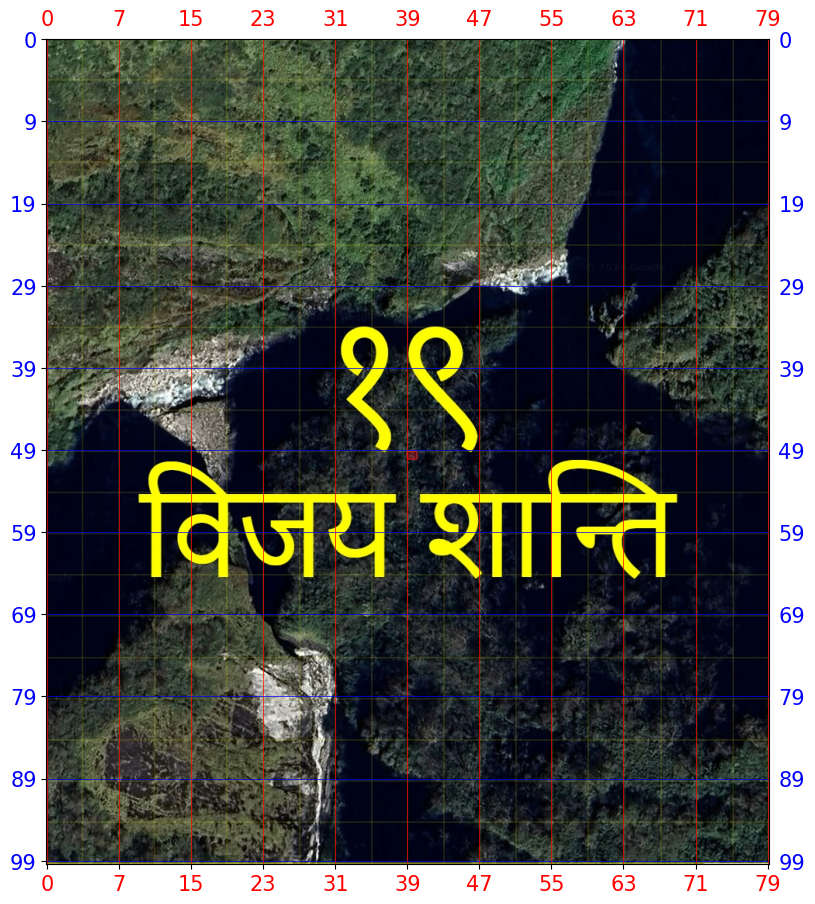

In [83]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cv2

image = cv2.cvtColor(box_1x1, cv2.COLOR_BGR2RGB)  # Convert to RGB for Matplotlib

# Create the figure and axis
fig, ax = plt.subplots(figsize=(9.32, 10.58*1.2))

# Display the image
ax.imshow(image)

# Add grid lines
major_ticks_x = image.shape[1]//10  # Distance between major ticks
major_ticks = image.shape[0]//10  # Distance between major ticks
minor_ticks_x = 8  # Distance between minor ticks
minor_ticks = 11  # Distance between minor ticks

n_x_ele = len(range(0, image.shape[1], major_ticks_x))
elements_x = [ele if i//n_x_ele < 0.5 else ele+1 for i, ele in enumerate(range(0, image.shape[1], major_ticks_x))]
labels_x = ['00'] + [str(8*idx-1) if idx!=0 else str(8*idx) for idx in range(n_x_ele)]

plt.tick_params(axis='x', which='both', labeltop=True, labelbottom=True)
ax.set_xticks(elements_x, minor=True)
ax.set_xticklabels(labels=labels_x, fontdict={"color":"red", "size":15})

n_y_ele = len(range(0, image.shape[0], major_ticks))
elements = [ele if i//n_y_ele < 0.5 else ele+1   for i, ele in enumerate(range(0, image.shape[0], major_ticks))]
labels = ['00'] + [str(10*idx-1) if idx!=0 else str(10*idx) for idx in range(n_y_ele)]

plt.tick_params(axis='y', which='both', labelleft=True, labelright=True)
ax.set_yticks(elements, minor=True)
ax.set_yticklabels(labels=labels, fontdict={"color":"blue", "size":15})

ax.grid(axis ='x', which="major", color="red", linestyle="-", linewidth=0.5)
ax.grid(axis ='y', which="major", color="blue", linestyle="-", linewidth=0.5)

# Customize tick labels
ax.xaxis.set_major_locator(ticker.MultipleLocator(major_ticks_x))
ax.yaxis.set_major_locator(ticker.MultipleLocator(major_ticks))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_ticks_x))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor_ticks))

# Customize grid appearance
# ax.set_xticks(range(major_ticks))

plt.show()
fig.savefig("D:/Mausam/Learn/Kataho/Tile-Concat/data/24-dec-11/decorated-file2.png")


In [81]:
import numpy as np
data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
data = data.reshape(fig.canvas.get_width_height()[::-1] + (3,))
data.shape

C:\Users\devai\AppData\Local\Temp\ipykernel_25484\3980921714.py:2: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  data = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


(1269, 932, 3)

In [77]:
cv2.imshow('data', cv2.cvtColor(data, cv2.COLOR_BGR2RGB))
cv2.waitKey(0)

-1

In [184]:
elements_x

[0, 116, 232, 348, 464, 580, 696, 812, 928]

In [173]:
[ele if i//n_x_ele < 0.5 else ele+1 for i, ele in enumerate(range(0, image.shape[1], major_ticks_x))]

[0, 116, 232, 348, 464, 580, 696, 812, 928]

In [154]:
labels = [str(10*idx) for idx, ele in enumerate(elements)]
labels

['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']

In [160]:
[str(10*idx) for idx, ele in enumerate(elements)]

['0', '10', '20', '30', '40', '50', '60', '70', '80', '90', '100']

In [155]:
[ele if i//n_y_ele < 0.5 else ele+1   for i, ele in enumerate(range(0, image.shape[0], major_ticks))]

[0, 105, 210, 315, 420, 525, 630, 735, 840, 945, 1050]

In [8]:
image.shape[0]//10, image.shape[1]//10

(105, 93)

In [153]:
str(10*idx)

'20'

In [123]:
len(range(0, image.shape[1], image.shape[1]//20))

21

In [ ]:
def decorate_image(full_image, nr, nc):
        # full_image = cv2.cvtColor(full_image, cv2.COLOR_BGR2RGB)
        img_shape = full_image.shape[:2]

        fig, ax = plt.subplots(figsize=(img_shape[1] / 100, img_shape[0] / 100 * 1.25))

        # ax.imshow(full_image)

        # major and minor ticks defination
        major_ticks_x = full_image.shape[1] // 10  # Distance between major ticks
        major_ticks = full_image.shape[0] // 10  # Distance between major ticks
        minor_ticks_x = 8  # Distance between minor ticks
        minor_ticks = 11  # Distance between minor ticks

        n_x_ele = len(range(0, full_image.shape[1], major_ticks_x))
        elements_x = [
            ele if i // n_x_ele < 0.5 else ele + 1
            for i, ele in enumerate(range(0, full_image.shape[1], major_ticks_x))
        ]
        labels_x = [
            str(8 * idx - 1) if idx != 0 else str(8 * idx) for idx in range(n_x_ele)
        ]

        ax.set_xticks(elements_x, minor=True)
        ax.set_xticklabels(labels=labels_x, fontdict={"color": "red", "size": 15})

        n_y_ele = len(range(0, full_image.shape[0], major_ticks))
        elements = [
            ele if i // n_y_ele < 0.5 else ele + 1
            for i, ele in enumerate(range(0, full_image.shape[0], major_ticks))
        ]
        labels = [
            str(10 * idx - 1) if idx != 0 else str(10 * idx) for idx in range(n_y_ele)
        ]

        ax.set_yticks(elements, minor=True)
        ax.set_yticklabels(labels=labels, fontdict={"color": "blue", "size": 15})

        ax.grid(axis="x", which="major", color="red", linestyle="-", linewidth=0.5)
        ax.grid(axis="y", which="major", color="blue", linestyle="-", linewidth=0.5)

        # Customize tick labels
        ax.xaxis.set_major_locator(ticker.MultipleLocator(major_ticks_x))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(major_ticks))

        plt.tick_params(axis="x", which="both", labeltop=True, labelbottom=True)
        plt.tick_params(axis="y", which="both", labelleft=True, labelright=True)
        # fig.savefig(
        #     "D:/Mausam/Learn/Kataho/Tile-Concat/data/24-dec-11/decorated-file2.png"
        # )

        full_image = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        # full_image = full_image.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        return full_image
    
full_image = decorate_image(cv2.imread(filepath.name), nr, nc)